# Analysis Notebook 

The following notebook was used by us to:

1. evaluates faithfulness (insertion/deletion AUC)
2. runs mandatory Grad-CAM++ diagnostics

**Note for TAs**: We have included a zip of the models we trained (with seed 0 for model initialization) in the submission and a dedicated notebook cell for quickly reproducing results without running the full notebook. Please scroll down to the Seed Checkpoints section.

In [7]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path
import json
import sys

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_ROOT = PROJECT_ROOT / "src"
if not SRC_ROOT.exists():
    raise FileNotFoundError(f"Could not find src/ under {PROJECT_ROOT}")
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from cv.analysis import (
    classify_gradcampp_outcome,
    compute_method_deltas,
    compute_primary_correct_intersection,
    deletion_auc,
    insertion_auc,
    paired_bootstrap_ci,
    paired_permutation_pvalue,
    run_insertion_deletion,
    summarize_condition_level_deltas,
    summarize_condition_level_metrics,
    summarize_seed_level_deltas,
    summarize_seed_level_metrics,
)
from cv.config import ARTIFACTS_ROOT, DEFAULT_ENCODER_CHECKPOINTS
from cv.data import load_eval_subset, load_stl10_split
from cv.explain import discover_stage4_runs, load_saliency_map, read_saliency_metadata
from cv.models import build_downstream_model, resolve_mode_config
from cv.train.trainer import TrainingRunConfig, train_one_run
from cv.transforms import build_eval_transform
from cv.utils.io import ensure_parent, read_json, write_json


In [8]:
RUN_CONFIG: dict[str, object] = {
    "artifacts_root": None, # path for saving outputs, defaults to artifacts
    "data_root": None, # optional override for STL-10 data 
    "device": "cuda" if torch.cuda.is_available() else "cpu", # device used for model loading and inference for perturbation evals   
    "allow_remote_download": False, # do not download encoders again for eval
    "conditions": ["supervised", "moco", "swav", "random_init"],
    "seeds": [0, 1, 2],
    "methods": ["gradcam", "gradcampp", "occlusion"], # saliency methods to evaluate 
    "patch_size": 16,
    "stride": 16,
    "blur_kernel_size": 21, # gaussian blur kernel size for making blurred baseline 
    # and perturbations, larger = stronger smoothing 
    "blur_sigma": 5.0, # std for gaussian blur 
    "eval_batch_size": 200, # model batch size 
    "bootstrap_resamples": 1000, # number of paired bootstrap resamples for confidence intervals  
    "permutation_resamples": 5000, # number of resamples for paired permutation p values for insertion 
    # and deletion AUC
    "gradcampp_effect_threshold": 0.01, # for deciding meaningfulness of gradCAM++ values 
    
    # ablation configs 
    "run_stage8_ablation": False, # ablation fine tuning flag 
    "stage8_conditions": ["supervised", "moco", "swav"],
    "stage8_seed": 0, 
    "stage8_recipe_id": "ablation_layer4_v1", # hyperparam config for ablation 
    # (layer4 + classifier training). NOTE: encoders are not retrained and remain frozen 
    "stage8_num_workers": 0, # dataloader worker config 
    "stage8_pin_memory": False, # false for CPU
    "stage8_sanity_checks": True, # gradient/BN/training check before full fine tuning 
    "primary_slice_policy": "all_conditions_correct_intersection", # for permutation slices 
    "stage9_panel_seed": 0,
    "stage9_panel_reference_condition": "supervised", # reference for picking IDs 
    "stage9_panel_num_images": 3, # number of image IDs to include for plotting 
    "stage9_panel_image_ids": None, # auto select
}

ARTIFACTS_ROOT_RESOLVED = Path(RUN_CONFIG["artifacts_root"]) if RUN_CONFIG["artifacts_root"] else ARTIFACTS_ROOT
print(json.dumps(RUN_CONFIG, indent=2))
print(f"Resolved artifacts root: {ARTIFACTS_ROOT_RESOLVED}")


{
  "artifacts_root": null,
  "data_root": null,
  "device": "cuda",
  "allow_remote_download": false,
  "conditions": [
    "supervised",
    "moco",
    "swav",
    "random_init"
  ],
  "seeds": [
    0,
    1,
    2
  ],
  "methods": [
    "gradcam",
    "gradcampp",
    "occlusion"
  ],
  "patch_size": 16,
  "stride": 16,
  "blur_kernel_size": 21,
  "blur_sigma": 5.0,
  "eval_batch_size": 200,
  "bootstrap_resamples": 1000,
  "permutation_resamples": 5000,
  "gradcampp_effect_threshold": 0.01,
  "run_stage8_ablation": false,
  "stage8_conditions": [
    "supervised",
    "moco",
    "swav"
  ],
  "stage8_seed": 0,
  "stage8_recipe_id": "ablation_layer4_v1",
  "stage8_num_workers": 0,
  "stage8_pin_memory": false,
  "stage8_sanity_checks": true,
  "primary_slice_policy": "all_conditions_correct_intersection",
  "stage9_panel_seed": 0,
  "stage9_panel_reference_condition": "supervised",
  "stage9_panel_num_images": 3,
  "stage9_panel_image_ids": null
}
Resolved artifacts root: /lustr

In [9]:
def _load_stage4_model(*, run, device: str, allow_remote_download: bool):
    mode_config = resolve_mode_config(condition=run.condition, training_mode=run.training_mode)

    checkpoint_path = None
    if run.condition == "moco":
        checkpoint_path = str(DEFAULT_ENCODER_CHECKPOINTS.moco_checkpoint_path)
    elif run.condition == "swav":
        checkpoint_path = str(DEFAULT_ENCODER_CHECKPOINTS.swav_checkpoint_path)

    model = build_downstream_model(
        condition=run.condition,
        num_classes=10,
        freeze_encoder=mode_config.freeze_encoder,
        trainable_layer4=mode_config.trainable_layer4,
        device=torch.device(device),
        allow_remote_download=allow_remote_download,
        checkpoint_path=checkpoint_path,
    )

    payload = torch.load(run.checkpoint_path, map_location=torch.device(device), weights_only=False)
    model.load_state_dict(payload["model_state_dict"])
    model.eval()
    return model


def _metadata_path(*, artifacts_root: Path, condition: str, seed: int, method: str) -> Path:
    return artifacts_root / "saliency" / condition / f"seed_{seed}" / method / "metadata.json"


def _resolve_map_path(path_value: str, artifacts_root: Path) -> Path:
    path = Path(path_value)
    if path.is_absolute():
        return path
    return artifacts_root / path


def _index_rows_by_image_id(rows: list[dict[str, object]]) -> dict[int, dict[str, object]]:
    indexed: dict[int, dict[str, object]] = {}
    for row in rows:
        image_id = row.get("test_image_id")
        if not isinstance(image_id, int):
            raise ValueError(f"Row missing integer test_image_id: {row}")
        if image_id in indexed:
            raise ValueError(f"Duplicate test_image_id in metadata: {image_id}")
        indexed[image_id] = row
    return indexed


## Stage 7: Make Subsets for AUC summaries and permutation tests 

This notebook uses 2 different slices for evals, `all200`, all images in the fixed eval subset, and `primary`, a stricter subset where for a given seed, the image was correctly classified by all conditions that are being compared against each other (all models identified this sample correctly).

- loads fixed eval subset IDs
- load saliency metadata for each condition, seed and method
- find the correctly identified samples per seed ("for each seed X models, find the samples where all models correctly classified it, and get the ID for the sample to create the `primary` subset").
- stores the IDs as `primary_ids_by_seed`

In [10]:
subset_artifacts = load_eval_subset(artifacts_root=RUN_CONFIG["artifacts_root"])
subset_ids = sorted(int(idx) for idx in subset_artifacts.indices)

runs = discover_stage4_runs(
    artifacts_root=RUN_CONFIG["artifacts_root"],
    conditions=list(RUN_CONFIG["conditions"]),
    seeds=[int(seed) for seed in list(RUN_CONFIG["seeds"])],
)
run_lookup = {(run.condition, int(run.seed)): run for run in runs}

metadata_rows: list[dict[str, object]] = []
metadata_by_key: dict[tuple[str, int, str], list[dict[str, object]]] = {}
for condition in list(RUN_CONFIG["conditions"]):
    for seed in [int(s) for s in list(RUN_CONFIG["seeds"])]:
        if (condition, seed) not in run_lookup:
            raise FileNotFoundError(f"Missing Stage-4 run metrics for {condition}/seed_{seed}.")
        for method in list(RUN_CONFIG["methods"]):
            metadata_path = _metadata_path(
                artifacts_root=ARTIFACTS_ROOT_RESOLVED,
                condition=condition,
                seed=seed,
                method=method,
            )
            if not metadata_path.exists():
                raise FileNotFoundError(f"Missing saliency metadata: {metadata_path}")
            rows = read_saliency_metadata(metadata_path)
            metadata_by_key[(condition, seed, method)] = rows
            metadata_rows.extend(rows)

primary_ids_by_seed = compute_primary_correct_intersection(
    metadata_rows,
    conditions=list(RUN_CONFIG["conditions"]),
    seeds=[int(seed) for seed in list(RUN_CONFIG["seeds"])],
)

primary_counts_df = pd.DataFrame(
    [
        {"seed": seed, "n_primary": len(ids), "n_all": len(subset_ids)}
        for seed, ids in sorted(primary_ids_by_seed.items())
    ]
)
display(primary_counts_df)
print(f"Fixed eval subset size: {len(subset_ids)}")


,seed,n_primary,n_all
0,0,127,200
1,1,118,200
2,2,123,200


Fixed eval subset size: 200


## Stage 7: Per-Image AUC Computation and Aggregation


[eval] condition=supervised seed=0
[eval] condition=supervised seed=1
[eval] condition=supervised seed=2
[eval] condition=moco seed=0
[eval] condition=moco seed=1
[eval] condition=moco seed=2
[eval] condition=swav seed=0
[eval] condition=swav seed=1
[eval] condition=swav seed=2
[eval] condition=random_init seed=0
[eval] condition=random_init seed=1
[eval] condition=random_init seed=2


,condition,seed,method,slice,n_images,mean_insertion_auc,mean_deletion_auc,mean_target_logit_original,mean_norm_insertion_auc,mean_norm_deletion_auc,mean_drop_top10,mean_drop_top20,flip_rate_top10,flip_rate_top20
0,moco,0,gradcam,all200,200,0.519919,0.298178,0.706122,0.743331,0.434174,0.132972,0.279516,0.060000,0.155000
1,moco,0,gradcam,primary,127,0.567459,0.316310,0.755565,0.757269,0.426282,0.123642,0.291771,0.031496,0.102362
2,moco,0,gradcampp,all200,200,0.512617,0.303542,0.706122,0.730827,0.442509,0.125556,0.269078,0.070000,0.140000
3,moco,0,gradcampp,primary,127,0.559943,0.321186,0.755565,0.746650,0.432540,0.116763,0.280589,0.039370,0.086614
4,moco,0,occlusion,all200,200,0.482575,0.289376,0.706122,0.700808,0.416971,0.246010,0.318830,0.160000,0.230000


,condition,method,slice,n_seeds,mean_insertion_auc,std_insertion_auc,mean_deletion_auc,std_deletion_auc,mean_n_images,min_n_images,max_n_images
0,moco,gradcam,all200,3,0.527494,0.008333,0.302545,0.004897,200.000000,200,200
1,moco,gradcam,primary,3,0.577827,0.009924,0.328504,0.010993,122.666667,118,127
2,moco,gradcampp,all200,3,0.520121,0.008269,0.307957,0.005007,200.000000,200,200
3,moco,gradcampp,primary,3,0.570259,0.009765,0.333071,0.010884,122.666667,118,127
4,moco,occlusion,all200,3,0.488984,0.006965,0.293823,0.005028,200.000000,200,200
5,moco,occlusion,primary,3,0.534749,0.014559,0.326442,0.007820,122.666667,118,127
6,random_init,gradcam,all200,3,0.710240,0.004574,0.633464,0.026738,200.000000,200,200
7,random_init,gradcam,primary,3,0.800346,0.006624,0.716450,0.017334,122.666667,118,127
8,random_init,gradcampp,all200,3,0.699500,0.003514,0.644057,0.029395,200.000000,200,200
9,random_init,gradcampp,primary,3,0.791129,0.003471,0.726847,0.022622,122.666667,118,127


,method,seed,condition_a,condition_b,n_images,delta_ins_mean,delta_ins_ci_low,delta_ins_ci_high,delta_ins_pvalue,delta_del_mean,delta_del_ci_low,delta_del_ci_high,delta_del_pvalue
0,gradcam,0,supervised,moco,127,-0.371233,-0.397679,-0.346498,0.0002,-0.542271,-0.569103,-0.515477,0.0002
1,gradcam,0,supervised,swav,127,-0.081467,-0.095990,-0.067026,0.0002,-0.262514,-0.290893,-0.234342,0.0002
2,gradcam,0,supervised,random_init,127,-0.145583,-0.184405,-0.106249,0.0002,-0.160470,-0.216568,-0.112313,0.0002
3,gradcam,0,moco,swav,127,0.289765,0.265810,0.315513,0.0002,0.279757,0.251386,0.307224,0.0002
4,gradcam,0,moco,random_init,127,0.225650,0.188654,0.261467,0.0002,0.381802,0.333653,0.424924,0.0002


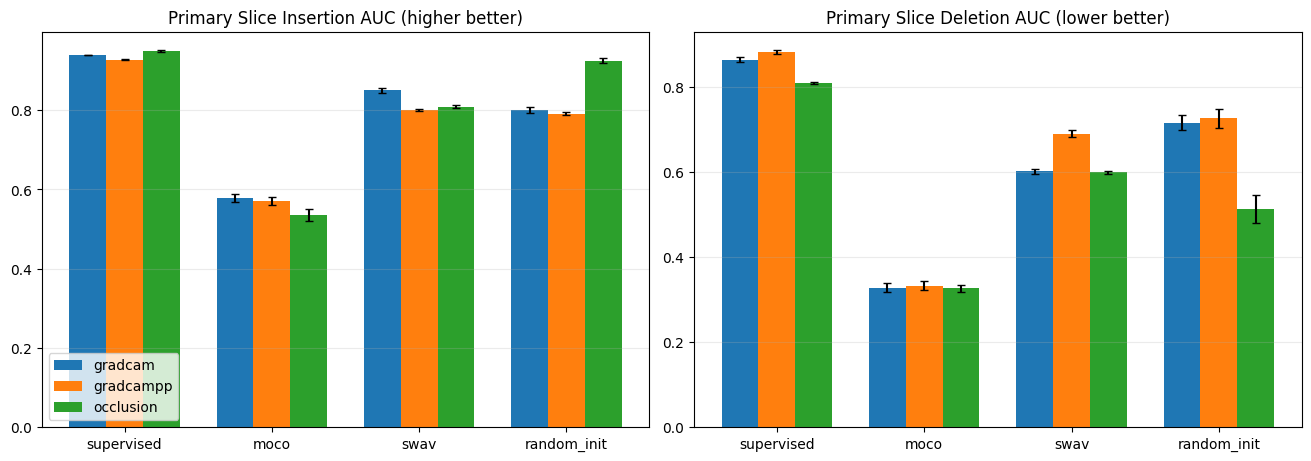

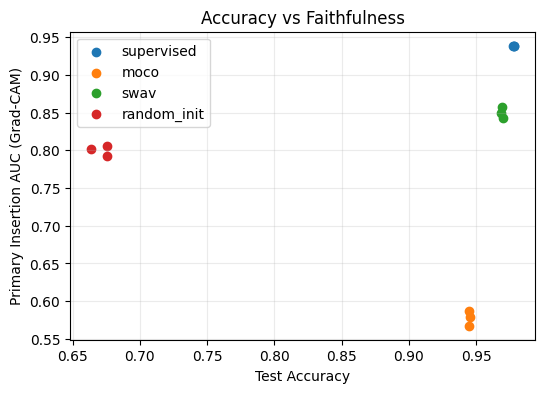

In [11]:
test_dataset = load_stl10_split(
    "test",
    transform=build_eval_transform(),
    data_root=RUN_CONFIG["data_root"],
    download=False,
)

per_image_rows: list[dict[str, object]] = []
for condition in list(RUN_CONFIG["conditions"]):
    for seed in [int(s) for s in list(RUN_CONFIG["seeds"])]:
        print(f"[eval] condition={condition} seed={seed}")
        run = run_lookup[(condition, seed)]
        model = _load_stage4_model(
            run=run,
            device=str(RUN_CONFIG["device"]),
            allow_remote_download=bool(RUN_CONFIG["allow_remote_download"]),
        )

        primary_ids = set(primary_ids_by_seed[seed])
        for method in list(RUN_CONFIG["methods"]):
            method_rows = metadata_by_key[(condition, seed, method)]
            rows_by_image = _index_rows_by_image_id(method_rows)

            missing_ids = sorted(set(subset_ids) - set(rows_by_image))
            if missing_ids:
                raise ValueError(
                    f"Missing metadata rows for {condition}/seed_{seed}/{method}: {missing_ids[:5]}..."
                )

            for image_id in subset_ids:
                row = rows_by_image[image_id]
                image, _ = test_dataset[image_id]
                map_path = _resolve_map_path(str(row["saliency_map_path"]), ARTIFACTS_ROOT_RESOLVED)
                saliency = load_saliency_map(map_path)

                result = run_insertion_deletion(
                    model=model,
                    image=image,
                    saliency=saliency,
                    target_class=int(row["predicted_class"]),
                    patch_size=int(RUN_CONFIG["patch_size"]),
                    stride=int(RUN_CONFIG["stride"]),
                    blur_kernel_size=int(RUN_CONFIG["blur_kernel_size"]),
                    blur_sigma=float(RUN_CONFIG["blur_sigma"]),
                    eval_batch_size=int(RUN_CONFIG["eval_batch_size"]),
                    device=str(RUN_CONFIG["device"]),
                )

                ins_auc = insertion_auc(result.insertion_scores, x=result.x)
                del_auc = deletion_auc(result.deletion_scores, x=result.x)
                t_orig = float(result.target_logit_original)
                t_base = float(result.insertion_scores[0])
                random_auc = (t_orig + t_base) / 2.0
                auc_range = max(t_orig - t_base, 1e-8)
                base_row = {
                    "condition": condition,
                    "seed": seed,
                    "method": method,
                    "test_image_id": int(image_id),
                    "predicted_class": int(row["predicted_class"]),
                    "true_class": int(row["true_class"]),
                    "correct": bool(row["correct"]),
                    "insertion_auc": ins_auc,
                    "deletion_auc": del_auc,
                    "target_logit_original": t_orig,
                    "baseline_confidence": t_base,
                    "random_baseline_auc": random_auc,
                    "norm_insertion_auc": (ins_auc - random_auc) / auc_range,
                    "norm_deletion_auc": (del_auc - random_auc) / auc_range,
                    "drop_top10": float(result.drop_top10),
                    "drop_top20": float(result.drop_top20),
                    "flip_top10": bool(result.flip_at_top10),
                    "flip_top20": bool(result.flip_at_top20),
                }

                per_image_rows.append({**base_row, "slice": "all200"})
                if image_id in primary_ids:
                    per_image_rows.append({**base_row, "slice": "primary"})

per_image_df = pd.DataFrame(per_image_rows)
if per_image_df.empty:
    raise RuntimeError("No per-image rows were generated.")

seed_summary_rows = summarize_seed_level_metrics(per_image_rows)
condition_summary_rows = summarize_condition_level_metrics(seed_summary_rows)
seed_summary_df = pd.DataFrame(seed_summary_rows)
condition_summary_df = pd.DataFrame(condition_summary_rows)
display(seed_summary_df.head())
display(condition_summary_df)

faithfulness_root = ARTIFACTS_ROOT_RESOLVED / "metrics" / "faithfulness"
per_image_csv = faithfulness_root / "per_image_scores.csv"
seed_summary_csv = faithfulness_root / "seed_level_scores.csv"
condition_summary_csv = faithfulness_root / "condition_summary.csv"
per_image_json = faithfulness_root / "per_image_scores.json"

ensure_parent(per_image_csv)
per_image_df.to_csv(per_image_csv, index=False)
seed_summary_df.to_csv(seed_summary_csv, index=False)
condition_summary_df.to_csv(condition_summary_csv, index=False)
write_json(per_image_json, per_image_rows)

paired_rows: list[dict[str, object]] = []
primary_df = per_image_df[per_image_df["slice"] == "primary"]
for method in list(RUN_CONFIG["methods"]):
    method_df = primary_df[primary_df["method"] == method]
    for seed in [int(s) for s in list(RUN_CONFIG["seeds"])]:
        seed_df = method_df[method_df["seed"] == seed]
        for condition_a, condition_b in combinations(list(RUN_CONFIG["conditions"]), 2):
            a_df = seed_df[seed_df["condition"] == condition_a][["test_image_id", "insertion_auc", "deletion_auc"]]
            b_df = seed_df[seed_df["condition"] == condition_b][["test_image_id", "insertion_auc", "deletion_auc"]]
            merged = a_df.merge(b_df, on="test_image_id", suffixes=("_a", "_b"))
            if merged.empty:
                continue

            ins_mean, ins_ci_low, ins_ci_high = paired_bootstrap_ci(
                merged["insertion_auc_a"].to_numpy(),
                merged["insertion_auc_b"].to_numpy(),
                num_resamples=int(RUN_CONFIG["bootstrap_resamples"]),
                seed=seed,
            )
            del_mean, del_ci_low, del_ci_high = paired_bootstrap_ci(
                merged["deletion_auc_a"].to_numpy(),
                merged["deletion_auc_b"].to_numpy(),
                num_resamples=int(RUN_CONFIG["bootstrap_resamples"]),
                seed=seed,
            )

            paired_rows.append(
                {
                    "method": method,
                    "seed": seed,
                    "condition_a": condition_a,
                    "condition_b": condition_b,
                    "n_images": int(merged.shape[0]),
                    "delta_ins_mean": float(ins_mean),
                    "delta_ins_ci_low": float(ins_ci_low),
                    "delta_ins_ci_high": float(ins_ci_high),
                    "delta_ins_pvalue": float(
                        paired_permutation_pvalue(
                            merged["insertion_auc_a"].to_numpy(),
                            merged["insertion_auc_b"].to_numpy(),
                            num_resamples=int(RUN_CONFIG["permutation_resamples"]),
                            seed=seed,
                        )
                    ),
                    "delta_del_mean": float(del_mean),
                    "delta_del_ci_low": float(del_ci_low),
                    "delta_del_ci_high": float(del_ci_high),
                    "delta_del_pvalue": float(
                        paired_permutation_pvalue(
                            merged["deletion_auc_a"].to_numpy(),
                            merged["deletion_auc_b"].to_numpy(),
                            num_resamples=int(RUN_CONFIG["permutation_resamples"]),
                            seed=seed,
                        )
                    ),
                }
            )

paired_df = pd.DataFrame(paired_rows)
paired_csv = faithfulness_root / "paired_stats_primary.csv"
paired_df.to_csv(paired_csv, index=False)
if not paired_df.empty:
    display(paired_df.head())

fig_root = faithfulness_root / "figures"
ensure_parent(fig_root / "placeholder.txt")

primary_summary = condition_summary_df[condition_summary_df["slice"] == "primary"]
methods = list(RUN_CONFIG["methods"])
conditions = list(RUN_CONFIG["conditions"])
x = np.arange(len(conditions))
width = 0.25
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for idx, method in enumerate(methods):
    offset = (idx - 1) * width
    method_df = primary_summary[primary_summary["method"] == method].set_index("condition")
    ins_vals = [float(method_df.loc[c, "mean_insertion_auc"]) for c in conditions]
    ins_err = [float(method_df.loc[c, "std_insertion_auc"]) for c in conditions]
    del_vals = [float(method_df.loc[c, "mean_deletion_auc"]) for c in conditions]
    del_err = [float(method_df.loc[c, "std_deletion_auc"]) for c in conditions]
    axes[0].bar(x + offset, ins_vals, width=width, yerr=ins_err, capsize=3, label=method)
    axes[1].bar(x + offset, del_vals, width=width, yerr=del_err, capsize=3, label=method)

axes[0].set_title("Primary Slice Insertion AUC (higher better)")
axes[1].set_title("Primary Slice Deletion AUC (lower better)")
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(conditions)
    ax.grid(axis="y", alpha=0.25)
axes[0].legend()
auc_fig_path = fig_root / "primary_auc_by_condition_method.png"
fig.savefig(auc_fig_path, dpi=200, bbox_inches="tight")
plt.show()

gradcam_seed = seed_summary_df[(seed_summary_df["slice"] == "primary") & (seed_summary_df["method"] == "gradcam")][["condition", "seed", "mean_insertion_auc", "mean_deletion_auc"]]
acc_rows = []
for run in runs:
    payload = read_json(run.run_metrics_path)
    acc_rows.append({"condition": run.condition, "seed": int(run.seed), "test_acc": float(payload["test_acc"])})
acc_df = pd.DataFrame(acc_rows)
merged_df = gradcam_seed.merge(acc_df, on=["condition", "seed"], how="inner")
fig, ax = plt.subplots(figsize=(6, 4))
for condition in conditions:
    sub = merged_df[merged_df["condition"] == condition]
    ax.scatter(sub["test_acc"], sub["mean_insertion_auc"], label=condition)
ax.set_xlabel("Test Accuracy")
ax.set_ylabel("Primary Insertion AUC (Grad-CAM)")
ax.set_title("Accuracy vs Faithfulness")
ax.grid(alpha=0.25)
ax.legend()
acc_fig_path = fig_root / "accuracy_vs_faithfulness.png"
fig.savefig(acc_fig_path, dpi=200, bbox_inches="tight")
plt.show()


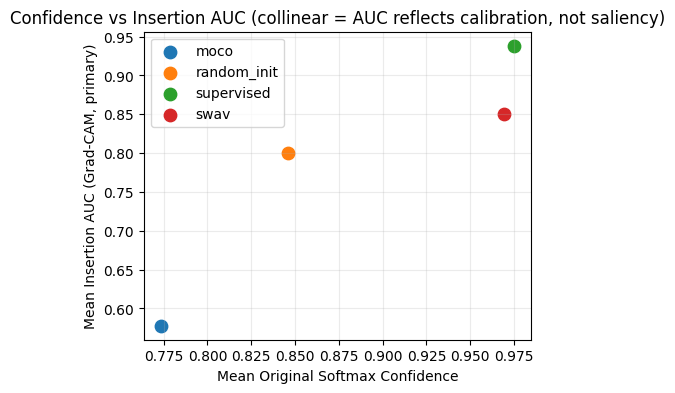

Confidence-normalized AUC (Grad-CAM, primary):
  condition  mean_target_logit_original  mean_norm_insertion_auc  mean_norm_deletion_auc
       moco                    0.773781                 0.751616                0.431742
random_init                    0.845920                 0.944740                0.835313
 supervised                    0.974831                 0.962429                0.885354
       swav                    0.969004                 0.876259                0.616151
Saved Stage-7 artifacts under: /lustre06/project/6040457/noahkost/cnn-benchmark/pretraining-saliency-downstream-classifiers/artifacts/metrics/faithfulness


In [12]:
# --- Confidence confound diagnostic ---
# If mean_target_logit_original tracks insertion AUC tightly, the ranking reflects
# model confidence calibration rather than explanation quality.
if "mean_target_logit_original" in seed_summary_df.columns:
    gcam_primary = (
        seed_summary_df[
            (seed_summary_df["slice"] == "primary")
            & (seed_summary_df["method"] == "gradcam")
        ]
        .groupby("condition")[
            [
                "mean_target_logit_original",
                "mean_norm_insertion_auc",
                "mean_norm_deletion_auc",
                "mean_insertion_auc",
            ]
        ]
        .mean()
        .reset_index()
    )
    fig2, ax2 = plt.subplots(figsize=(5, 4))
    for _, r in gcam_primary.iterrows():
        ax2.scatter(r["mean_target_logit_original"], r["mean_insertion_auc"], label=str(r["condition"]), s=80)
    ax2.set_xlabel("Mean Original Softmax Confidence")
    ax2.set_ylabel("Mean Insertion AUC (Grad-CAM, primary)")
    ax2.set_title("Confidence vs Insertion AUC (collinear = AUC reflects calibration, not saliency)")
    ax2.legend()
    ax2.grid(alpha=0.25)
    conf_fig_path = fig_root / "confidence_vs_insertion_auc.png"
    fig2.savefig(conf_fig_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Confidence-normalized AUC (Grad-CAM, primary):")
    print(gcam_primary[["condition", "mean_target_logit_original", "mean_norm_insertion_auc", "mean_norm_deletion_auc"]].to_string(index=False))
print(f"Saved Stage-7 artifacts under: {faithfulness_root}")

## Stage 8: Grad-CAM++ Diagnostics

In [13]:
primary_rows = [
    row for row in per_image_rows if row["slice"] == "primary" and row["method"] in {"gradcam", "gradcampp"}
]
delta_rows = compute_method_deltas(primary_rows, method_a="gradcam", method_b="gradcampp")
seed_delta_rows = summarize_seed_level_deltas(delta_rows)
condition_delta_rows = summarize_condition_level_deltas(seed_delta_rows)

seed_delta_df = pd.DataFrame(seed_delta_rows)
condition_delta_df = pd.DataFrame(condition_delta_rows)

seed_method_df = seed_summary_df[
    (seed_summary_df["slice"] == "primary") & seed_summary_df["method"].isin(["gradcam", "gradcampp"])
]
gradcam_df = seed_method_df[seed_method_df["method"] == "gradcam"].rename(
    columns={"mean_insertion_auc": "gradcam_ins", "mean_deletion_auc": "gradcam_del"}
)[["condition", "seed", "gradcam_ins", "gradcam_del"]]
gradcampp_df = seed_method_df[seed_method_df["method"] == "gradcampp"].rename(
    columns={"mean_insertion_auc": "gradcampp_ins", "mean_deletion_auc": "gradcampp_del"}
)[["condition", "seed", "gradcampp_ins", "gradcampp_del"]]

n_primary_df = seed_method_df[seed_method_df["method"] == "gradcam"][["condition", "seed", "n_images"]].rename(
    columns={"n_images": "n_primary"}
)

seed_method_delta_df = gradcam_df.merge(gradcampp_df, on=["condition", "seed"], how="inner")
seed_method_delta_df = seed_method_delta_df.merge(n_primary_df, on=["condition", "seed"], how="left")
seed_method_delta_df["delta_ins"] = seed_method_delta_df["gradcampp_ins"] - seed_method_delta_df["gradcam_ins"]
seed_method_delta_df["delta_del"] = seed_method_delta_df["gradcampp_del"] - seed_method_delta_df["gradcam_del"]
seed_method_delta_df = seed_method_delta_df[
    [
        "condition",
        "seed",
        "n_primary",
        "gradcam_ins",
        "gradcampp_ins",
        "delta_ins",
        "gradcam_del",
        "gradcampp_del",
        "delta_del",
    ]
]

display(seed_method_delta_df)
display(seed_delta_df)
display(condition_delta_df)

primary_condition_deltas = [row for row in condition_delta_rows if row["slice"] == "primary"]
outcome_label = classify_gradcampp_outcome(
    primary_condition_deltas,
    threshold=float(RUN_CONFIG["gradcampp_effect_threshold"]),
)

label_to_statement = {
    "reinforce": "Grad-CAM++ diagnostics reinforce the primary interpretation.",
    "neutral": "Grad-CAM++ diagnostics are mostly neutral to the primary interpretation.",
    "weaken": "Grad-CAM++ diagnostics weaken the primary interpretation.",
    "mixed": "Grad-CAM++ diagnostics are mixed across conditions.",
}
diagnostics_note = label_to_statement[outcome_label]
print(f"Stage-9 Grad-CAM++ outcome label: {outcome_label}")
print(diagnostics_note)

diag_root = ARTIFACTS_ROOT_RESOLVED / "metrics" / "gradcampp_diagnostics"
seed_method_delta_csv = diag_root / "seed_level_method_and_delta_scores.csv"
seed_delta_csv = diag_root / "seed_level_deltas.csv"
condition_delta_csv = diag_root / "condition_level_deltas.csv"
outcome_label_json = diag_root / "outcome_label.json"
diagnostics_note_json = diag_root / "diagnostics_note.json"

ensure_parent(seed_method_delta_csv)
seed_method_delta_df.to_csv(seed_method_delta_csv, index=False)
seed_delta_df.to_csv(seed_delta_csv, index=False)
condition_delta_df.to_csv(condition_delta_csv, index=False)
write_json(
    outcome_label_json,
    {
        "label": outcome_label,
        "threshold": float(RUN_CONFIG["gradcampp_effect_threshold"]),
        "slice": "primary",
    },
)
write_json(
    diagnostics_note_json,
    {
        "label": outcome_label,
        "note": diagnostics_note,
        "threshold": float(RUN_CONFIG["gradcampp_effect_threshold"]),
        "n_primary_by_condition_seed": seed_method_delta_df[["condition", "seed", "n_primary"]].to_dict(orient="records"),
    },
)

print("Saved Stage-9 quantitative outputs:")
print(f"- seed method+delta CSV: {seed_method_delta_csv}")
print(f"- seed delta CSV:        {seed_delta_csv}")
print(f"- condition delta CSV:   {condition_delta_csv}")
print(f"- outcome label JSON:    {outcome_label_json}")
print(f"- diagnostics note JSON: {diagnostics_note_json}")


,condition,seed,n_primary,gradcam_ins,gradcampp_ins,delta_ins,gradcam_del,gradcampp_del,delta_del
0,moco,0,127,0.567459,0.559943,-0.007515,0.316310,0.321186,0.004875
1,moco,1,118,0.578786,0.571475,-0.007311,0.331544,0.335474,0.003930
2,moco,2,123,0.587237,0.579360,-0.007877,0.337656,0.342552,0.004896
3,random_init,0,127,0.793109,0.787715,-0.005394,0.698112,0.703373,0.005261
4,random_init,1,118,0.801823,0.791018,-0.010805,0.732566,0.748507,0.015941
5,random_init,2,123,0.806107,0.794655,-0.011453,0.718671,0.728662,0.009991
6,supervised,0,127,0.938691,0.928163,-0.010529,0.858582,0.876347,0.017765
7,supervised,1,118,0.937940,0.928609,-0.009331,0.871403,0.885179,0.013775
8,supervised,2,123,0.938022,0.925804,-0.012217,0.864934,0.883264,0.018330
9,swav,0,127,0.857224,0.802986,-0.054238,0.596067,0.688937,0.092869


,condition,seed,slice,method_a,method_b,n_images,mean_delta_insertion_auc,mean_delta_deletion_auc
0,moco,0,primary,gradcam,gradcampp,127,-0.007515,0.004875
1,moco,1,primary,gradcam,gradcampp,118,-0.007311,0.003930
2,moco,2,primary,gradcam,gradcampp,123,-0.007877,0.004896
3,random_init,0,primary,gradcam,gradcampp,127,-0.005394,0.005261
4,random_init,1,primary,gradcam,gradcampp,118,-0.010805,0.015941
5,random_init,2,primary,gradcam,gradcampp,123,-0.011453,0.009991
6,supervised,0,primary,gradcam,gradcampp,127,-0.010529,0.017765
7,supervised,1,primary,gradcam,gradcampp,118,-0.009331,0.013775
8,supervised,2,primary,gradcam,gradcampp,123,-0.012217,0.018330
9,swav,0,primary,gradcam,gradcampp,127,-0.054238,0.092869


,condition,slice,method_a,method_b,n_seeds,mean_delta_insertion_auc,std_delta_insertion_auc,mean_delta_deletion_auc,std_delta_deletion_auc,mean_n_images,min_n_images,max_n_images
0,moco,primary,gradcam,gradcampp,3,-0.007568,0.000287,0.004567,0.000552,122.666667,118,127
1,random_init,primary,gradcam,gradcampp,3,-0.009217,0.003327,0.010398,0.005352,122.666667,118,127
2,supervised,primary,gradcam,gradcampp,3,-0.010692,0.001450,0.016624,0.002483,122.666667,118,127
3,swav,primary,gradcam,gradcampp,3,-0.049530,0.004916,0.088623,0.005510,122.666667,118,127


Stage-9 Grad-CAM++ outcome label: mixed
Grad-CAM++ diagnostics are mixed across conditions.
Saved Stage-9 quantitative outputs:
- seed method+delta CSV: /lustre06/project/6040457/noahkost/cnn-benchmark/pretraining-saliency-downstream-classifiers/artifacts/metrics/gradcampp_diagnostics/seed_level_method_and_delta_scores.csv
- seed delta CSV:        /lustre06/project/6040457/noahkost/cnn-benchmark/pretraining-saliency-downstream-classifiers/artifacts/metrics/gradcampp_diagnostics/seed_level_deltas.csv
- condition delta CSV:   /lustre06/project/6040457/noahkost/cnn-benchmark/pretraining-saliency-downstream-classifiers/artifacts/metrics/gradcampp_diagnostics/condition_level_deltas.csv
- outcome label JSON:    /lustre06/project/6040457/noahkost/cnn-benchmark/pretraining-saliency-downstream-classifiers/artifacts/metrics/gradcampp_diagnostics/outcome_label.json
- diagnostics note JSON: /lustre06/project/6040457/noahkost/cnn-benchmark/pretraining-saliency-downstream-classifiers/artifacts/metri

Auto-selected panel ids (seed=0, primary slice — all conditions correct): [233, 380, 431] (127 eligible images, showing 3)


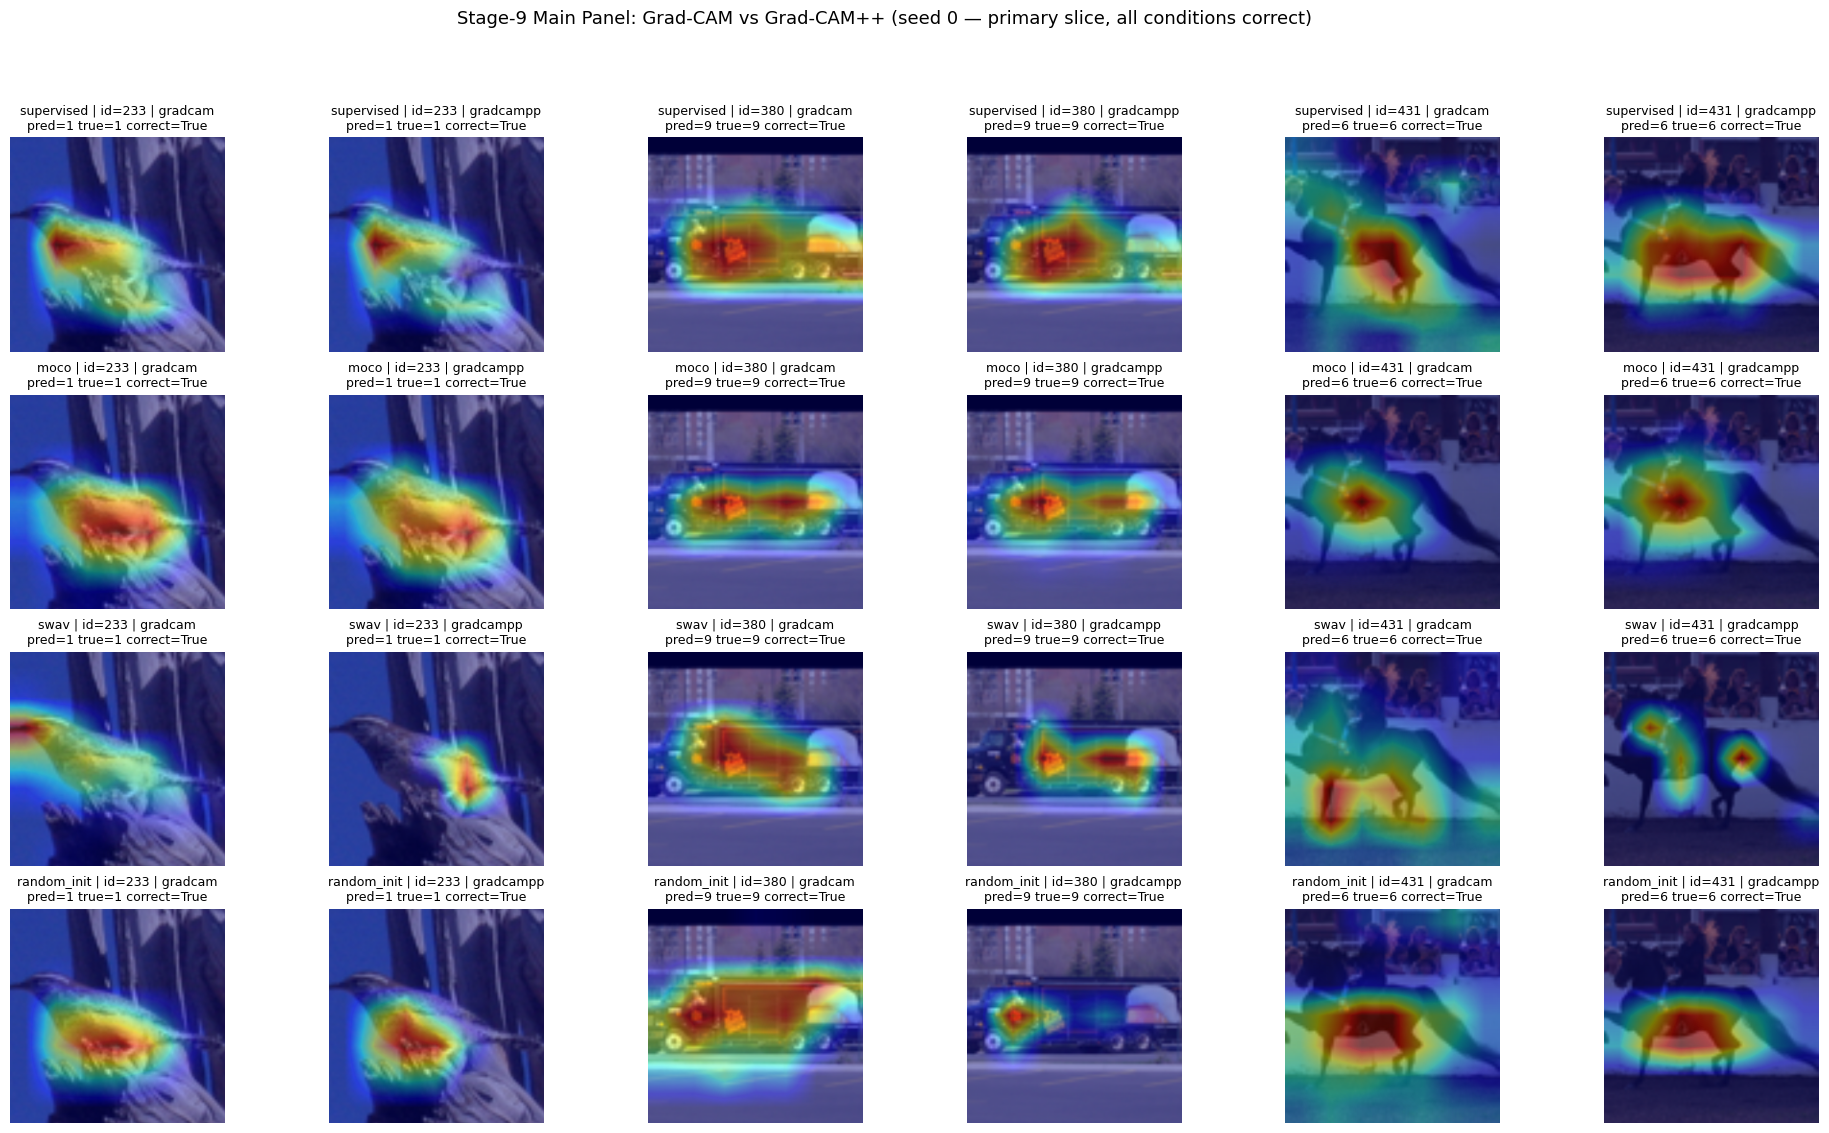

Saved Stage-9 main panel to: /lustre06/project/6040457/noahkost/cnn-benchmark/pretraining-saliency-downstream-classifiers/artifacts/saliency/gradcampp_diagnostics/main_panel/seed0_fixed_ids_panel.png


In [14]:
def _denormalize_image(image_tensor: torch.Tensor) -> np.ndarray:
    mean = np.asarray([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.asarray([0.229, 0.224, 0.225], dtype=np.float32)

    image = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
    image = image * std + mean

    return np.clip(image, 0.0, 1.0)


panel_seed = int(RUN_CONFIG["stage9_panel_seed"])
panel_ids = RUN_CONFIG["stage9_panel_image_ids"]

if panel_ids is None:
    panel_size = int(RUN_CONFIG["stage9_panel_num_images"])

    # Primary slice: only images where ALL conditions predict correctly
    all_indexed = {
        condition: _index_rows_by_image_id(
            metadata_by_key[(condition, panel_seed, "gradcam")]
        )
        for condition in list(RUN_CONFIG["conditions"])
    }

    primary_ids = [
        image_id
        for image_id in subset_ids
        if all(
            bool(all_indexed[cond][image_id]["correct"])
            for cond in all_indexed
        )
    ]

    panel_ids = [int(image_id) for image_id in primary_ids[:panel_size]]

    print(
        f"Auto-selected panel ids (seed={panel_seed}, primary slice — all conditions correct): "
        f"{panel_ids} ({len(primary_ids)} eligible images, showing {len(panel_ids)})"
    )
else:
    panel_ids = [int(image_id) for image_id in panel_ids]


if not panel_ids:
    print("No panel image ids available; skipping Stage-9 qualitative panel.")
else:
    panel_methods = ["gradcam", "gradcampp"]

    num_rows = len(list(RUN_CONFIG["conditions"]))
    num_cols = len(panel_ids) * len(panel_methods)

    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        figsize=(4.0 * num_cols, 3.2 * num_rows),
    )

    if num_rows == 1 and num_cols == 1:
        axes = np.asarray([[axes]])
    elif num_rows == 1:
        axes = np.expand_dims(axes, axis=0)
    elif num_cols == 1:
        axes = np.expand_dims(axes, axis=1)

    for row_idx, condition in enumerate(list(RUN_CONFIG["conditions"])):
        for image_offset, image_id in enumerate(panel_ids):
            image_tensor, _ = test_dataset[int(image_id)]
            image_vis = _denormalize_image(image_tensor)

            for method_offset, method in enumerate(panel_methods):
                col_idx = image_offset * len(panel_methods) + method_offset
                ax = axes[row_idx, col_idx]

                rows = metadata_by_key[(condition, panel_seed, method)]
                indexed = _index_rows_by_image_id(rows)
                meta = indexed[int(image_id)]

                saliency = load_saliency_map(
                    _resolve_map_path(
                        str(meta["saliency_map_path"]),
                        ARTIFACTS_ROOT_RESOLVED,
                    )
                )

                ax.imshow(image_vis)
                ax.imshow(
                    saliency,
                    cmap="jet",
                    alpha=0.45,
                    vmin=0.0,
                    vmax=1.0,
                )
                ax.set_axis_off()

                ax.set_title(
                    f"{condition} | id={image_id} | {method}\n"
                    f"pred={int(meta['predicted_class'])} "
                    f"true={int(meta['true_class'])} "
                    f"correct={bool(meta['correct'])}",
                    fontsize=9,
                )

    fig.suptitle(
        f"Stage-9 Main Panel: Grad-CAM vs Grad-CAM++ "
        f"(seed {panel_seed} — primary slice, all conditions correct)",
        fontsize=13,
    )

    panel_path = (
        ARTIFACTS_ROOT_RESOLVED
        / "saliency"
        / "gradcampp_diagnostics"
        / "main_panel"
        / f"seed{panel_seed}_fixed_ids_panel.png"
    )

    ensure_parent(panel_path)

    fig.savefig(panel_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved Stage-9 main panel to: {panel_path}")


## Seed Checkpoints: Zip Bundle and Restore for TAs.

The notebook cell below contains code for:

1. Packing model weights into a zip (run where `.pt` files already exist): builds `artifacts/bundles/seed0_probe_checkpoints.zip` with paths `checkpoints/<condition>/seed_0_....pt`.
2. Unpacking the zip: extracts the zip under `ARTIFACTS_ROOT_RESOLVED` and rewrites `checkpoint_path`/split paths in `metrics/probe_runs/**/**.json`.

Alternatively, you can also run shell commands if you already have the files under `artifacts/checkpoints/`:

```bash
mkdir -p artifacts/bundles
cd artifacts && zip -r bundles/seed0_probe_checkpoints.zip \
  checkpoints/supervised/seed_0_probe_recipe_v1.pt \
  checkpoints/moco/seed_0_probe_recipe_v1.pt \
  checkpoints/swav/seed_0_probe_recipe_v1.pt \
  checkpoints/random_init/seed_0_random_init_recipe_v1.pt
```

The code cell below defines `pack_seed0_probe_checkpoints()` and `unpack_seed0_probe_checkpoints()`.

In [15]:
import zipfile

from cv.explain import Stage4Run


def _seed0_frozen_probe_run(run: Stage4Run) -> bool:
    if run.training_mode != "frozen_probe" or int(run.seed) != 0:
        return False
    if run.condition == "random_init":
        return run.recipe_id == "random_init_recipe_v1"
    return run.recipe_id == "probe_recipe_v1"


SEED0_CHECKPOINT_BUNDLE = ARTIFACTS_ROOT_RESOLVED / "bundles" / "seed0_probe_checkpoints.zip"


def pack_seed0_probe_checkpoints() -> Path:
    """Zip the four seed-0 frozen-probe checkpoints; run on the machine that has the .pt files."""
    runs = discover_stage4_runs(
        artifacts_root=RUN_CONFIG["artifacts_root"],
        conditions=list(RUN_CONFIG["conditions"]),
        seeds=[0],
    )
    primary = [r for r in runs if _seed0_frozen_probe_run(r)]
    if len(primary) != len(list(RUN_CONFIG["conditions"])):
        got = {(r.condition, r.recipe_id, r.training_mode) for r in primary}
        raise RuntimeError(
            f"Expected one frozen_probe seed-0 run per condition; got {len(primary)} runs: {got}"
        )

    ensure_parent(SEED0_CHECKPOINT_BUNDLE)
    with zipfile.ZipFile(SEED0_CHECKPOINT_BUNDLE, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for run in primary:
            src = run.checkpoint_path
            if not src.exists():
                alt = ARTIFACTS_ROOT_RESOLVED / "checkpoints" / run.condition / run.checkpoint_path.name
                if alt.exists():
                    src = alt
                else:
                    raise FileNotFoundError(f"Checkpoint not found: {run.checkpoint_path} (also tried {alt})")
            arcname = Path("checkpoints") / run.condition / src.name
            zf.write(src, arcname.as_posix())
    print(f"Wrote {SEED0_CHECKPOINT_BUNDLE} ({len(primary)} files)")
    return SEED0_CHECKPOINT_BUNDLE


In [16]:
def unpack_seed0_probe_checkpoints(*, rewrite_json_paths: bool = True) -> None:
    """Extract bundle under ARTIFACTS_ROOT_RESOLVED; optionally fix absolute paths in probe JSON."""
    if not SEED0_CHECKPOINT_BUNDLE.exists():
        raise FileNotFoundError(
            f"Missing bundle: {SEED0_CHECKPOINT_BUNDLE}. Pack on the training machine or copy the zip here."
        )
    with zipfile.ZipFile(SEED0_CHECKPOINT_BUNDLE) as zf:
        zf.extractall(ARTIFACTS_ROOT_RESOLVED)
    print(f"Extracted under: {ARTIFACTS_ROOT_RESOLVED}")

    if not rewrite_json_paths:
        return

    probe_root = ARTIFACTS_ROOT_RESOLVED / "metrics" / "probe_runs"
    if not probe_root.exists():
        print(f"No probe_runs tree at {probe_root}; skip JSON rewrite.")
        return

    updated = 0
    for metrics_path in sorted(probe_root.glob("*/*.json")):
        if metrics_path.stem.endswith(".batch_losses") or metrics_path.stem.endswith(".epoch_losses"):
            continue
        payload = read_json(metrics_path)
        if not isinstance(payload, dict):
            continue
        try:
            run = Stage4Run(
                condition=str(payload["condition"]),
                seed=int(payload["seed"]),
                training_mode=str(payload["training_mode"]),
                recipe_id=str(payload["recipe_id"]),
                checkpoint_path=Path(str(payload["checkpoint_path"])),
                run_metrics_path=metrics_path,
            )
        except (KeyError, TypeError, ValueError):
            continue
        if not _seed0_frozen_probe_run(run):
            continue

        condition = run.condition
        cp_name = run.checkpoint_path.name
        payload = dict(payload)
        payload["checkpoint_path"] = str(ARTIFACTS_ROOT_RESOLVED / "checkpoints" / condition / cp_name)
        for key, subdir in (
            ("split_train_indices_path", "splits"),
            ("split_val_indices_path", "splits"),
            ("split_metadata_path", "splits"),
        ):
            if key in payload and payload[key]:
                payload[key] = str(ARTIFACTS_ROOT_RESOLVED / subdir / Path(str(payload[key])).name)
        write_json(metrics_path, payload)
        updated += 1

    print(f"Rewrote paths in {updated} seed-0 frozen_probe probe JSON file(s).")


# pack_seed0_probe_checkpoints()  # run where .pt files exist
# unpack_seed0_probe_checkpoints()  # run after copying the zip here, before repro

## Reproducing Results for TAs 

The notebook cell below is used for TAs to reproduce our results and analysis by running the notebook cells above. The code below uses **only the four `seed_0` checkpoints** zipped and want metrics that match those weights exactly.

- The cell below is **run after** the Stage 7–9 cells (or at least after Stage 7 metadata helpers). It uses **`repro_*` names only** so it does not overwrite `per_image_rows` / `seed_summary_df` required by Stage 9.
- It writes CSVs and figures under `artifacts/metrics/faithfulness_repro_seed0/` (separate from the main `faithfulness/` run, which should stay **three seeds** for paper summaries).
- It **skips** paired bootstrap CI / permutation tables here to keep runtime down; please use the stage 7 notebook cell and outputs for those.
- If you are on a fresh clone and only have `artifacts/bundles/seed0_probe_checkpoints.zip` and need to get model weights from a zip, please run **`unpack_seed0_probe_checkpoints()`** from the checkpoint bundle cell **above** before this cell.

[repro eval] condition=supervised seed=0
[repro eval] condition=moco seed=0
[repro eval] condition=swav seed=0
[repro eval] condition=random_init seed=0
Test accuracy (repro, seed 0):


,condition,seed,test_acc
0,moco,0,0.944875
1,random_init,0,0.675875
2,supervised,0,0.977750
3,swav,0,0.969125


Insertion / deletion AUC — primary slice (repro, seed 0):


,condition,method,mean_insertion_auc,mean_deletion_auc,n_seeds
1,moco,gradcam,0.567459,0.316310,1
7,random_init,gradcam,0.793109,0.698112,1
13,supervised,gradcam,0.938691,0.858582,1
19,swav,gradcam,0.857224,0.596067,1
3,moco,gradcampp,0.559943,0.321186,1
9,random_init,gradcampp,0.787715,0.703373,1
15,supervised,gradcampp,0.928163,0.876347,1
21,swav,gradcampp,0.802986,0.688937,1
5,moco,occlusion,0.519367,0.317570,1
11,random_init,occlusion,0.928053,0.485793,1


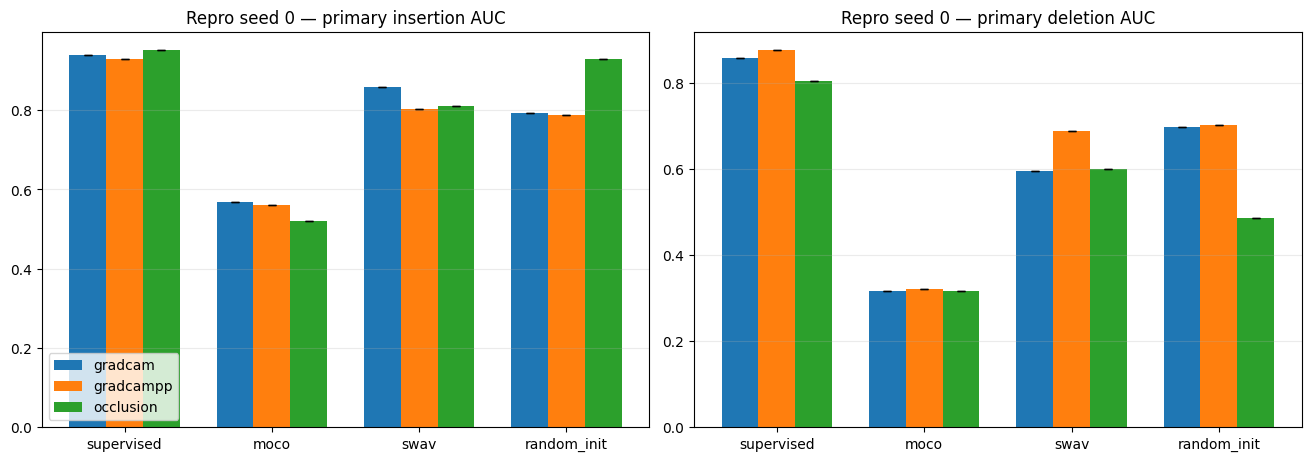

Saved repro faithfulness under: /lustre06/project/6040457/noahkost/cnn-benchmark/pretraining-saliency-downstream-classifiers/artifacts/metrics/faithfulness_repro_seed0


In [17]:
REPRO_SEEDS = [0]
REPRO_ROOT = ARTIFACTS_ROOT_RESOLVED / "metrics" / "faithfulness_repro_seed0"
REPRO_FIG_ROOT = REPRO_ROOT / "figures"

repro_subset_artifacts = load_eval_subset(artifacts_root=RUN_CONFIG["artifacts_root"])
repro_subset_ids = sorted(int(idx) for idx in repro_subset_artifacts.indices)

repro_runs = discover_stage4_runs(
    artifacts_root=RUN_CONFIG["artifacts_root"],
    conditions=list(RUN_CONFIG["conditions"]),
    seeds=[int(s) for s in REPRO_SEEDS],
)
repro_run_lookup = {(run.condition, int(run.seed)): run for run in repro_runs}

repro_metadata_rows: list[dict[str, object]] = []
repro_metadata_by_key: dict[tuple[str, int, str], list[dict[str, object]]] = {}
for condition in list(RUN_CONFIG["conditions"]):
    for seed in [int(s) for s in REPRO_SEEDS]:
        if (condition, seed) not in repro_run_lookup:
            raise FileNotFoundError(f"Missing Stage-4 run for repro {condition}/seed_{seed}.")
        for method in list(RUN_CONFIG["methods"]):
            metadata_path = _metadata_path(
                artifacts_root=ARTIFACTS_ROOT_RESOLVED,
                condition=condition,
                seed=seed,
                method=method,
            )
            if not metadata_path.exists():
                raise FileNotFoundError(f"Missing saliency metadata: {metadata_path}")
            rows = read_saliency_metadata(metadata_path)
            repro_metadata_by_key[(condition, seed, method)] = rows
            repro_metadata_rows.extend(rows)

repro_primary_ids_by_seed = compute_primary_correct_intersection(
    repro_metadata_rows,
    conditions=list(RUN_CONFIG["conditions"]),
    seeds=[int(s) for s in REPRO_SEEDS],
)

repro_test_dataset = load_stl10_split(
    "test",
    transform=build_eval_transform(),
    data_root=RUN_CONFIG["data_root"],
    download=False,
)

repro_per_image_rows: list[dict[str, object]] = []
for condition in list(RUN_CONFIG["conditions"]):
    for seed in [int(s) for s in REPRO_SEEDS]:
        print(f"[repro eval] condition={condition} seed={seed}")
        run = repro_run_lookup[(condition, seed)]
        model = _load_stage4_model(
            run=run,
            device=str(RUN_CONFIG["device"]),
            allow_remote_download=bool(RUN_CONFIG["allow_remote_download"]),
        )
        primary_ids = set(repro_primary_ids_by_seed[seed])
        for method in list(RUN_CONFIG["methods"]):
            method_rows = repro_metadata_by_key[(condition, seed, method)]
            rows_by_image = _index_rows_by_image_id(method_rows)
            missing_ids = sorted(set(repro_subset_ids) - set(rows_by_image))
            if missing_ids:
                raise ValueError(
                    f"Missing metadata rows for repro {condition}/seed_{seed}/{method}: {missing_ids[:5]}..."
                )
            for image_id in repro_subset_ids:
                row = rows_by_image[image_id]
                image, _ = repro_test_dataset[image_id]
                map_path = _resolve_map_path(str(row["saliency_map_path"]), ARTIFACTS_ROOT_RESOLVED)
                saliency = load_saliency_map(map_path)
                result = run_insertion_deletion(
                    model=model,
                    image=image,
                    saliency=saliency,
                    target_class=int(row["predicted_class"]),
                    patch_size=int(RUN_CONFIG["patch_size"]),
                    stride=int(RUN_CONFIG["stride"]),
                    blur_kernel_size=int(RUN_CONFIG["blur_kernel_size"]),
                    blur_sigma=float(RUN_CONFIG["blur_sigma"]),
                    eval_batch_size=int(RUN_CONFIG["eval_batch_size"]),
                    device=str(RUN_CONFIG["device"]),
                )
                ins_auc = insertion_auc(result.insertion_scores, x=result.x)
                del_auc = deletion_auc(result.deletion_scores, x=result.x)
                t_orig = float(result.target_logit_original)
                t_base = float(result.insertion_scores[0])
                random_auc = (t_orig + t_base) / 2.0
                auc_range = max(t_orig - t_base, 1e-8)
                base_row = {
                    "condition": condition,
                    "seed": seed,
                    "method": method,
                    "test_image_id": int(image_id),
                    "predicted_class": int(row["predicted_class"]),
                    "true_class": int(row["true_class"]),
                    "correct": bool(row["correct"]),
                    "insertion_auc": ins_auc,
                    "deletion_auc": del_auc,
                    "target_logit_original": t_orig,
                    "baseline_confidence": t_base,
                    "random_baseline_auc": random_auc,
                    "norm_insertion_auc": (ins_auc - random_auc) / auc_range,
                    "norm_deletion_auc": (del_auc - random_auc) / auc_range,
                    "drop_top10": float(result.drop_top10),
                    "drop_top20": float(result.drop_top20),
                    "flip_top10": bool(result.flip_at_top10),
                    "flip_top20": bool(result.flip_at_top20),
                }
                repro_per_image_rows.append({**base_row, "slice": "all200"})
                if image_id in primary_ids:
                    repro_per_image_rows.append({**base_row, "slice": "primary"})

repro_per_image_df = pd.DataFrame(repro_per_image_rows)
if repro_per_image_df.empty:
    raise RuntimeError("No repro per-image rows were generated.")

repro_seed_summary_rows = summarize_seed_level_metrics(repro_per_image_rows)
repro_condition_summary_rows = summarize_condition_level_metrics(repro_seed_summary_rows)
repro_seed_summary_df = pd.DataFrame(repro_seed_summary_rows)
repro_condition_summary_df = pd.DataFrame(repro_condition_summary_rows)

ensure_parent(REPRO_ROOT / "per_image_scores.csv")
repro_per_image_df.to_csv(REPRO_ROOT / "per_image_scores.csv", index=False)
repro_seed_summary_df.to_csv(REPRO_ROOT / "seed_level_scores.csv", index=False)
repro_condition_summary_df.to_csv(REPRO_ROOT / "condition_summary.csv", index=False)
write_json(REPRO_ROOT / "per_image_scores.json", repro_per_image_rows)

repro_acc_rows = []
for run in repro_runs:
    payload = read_json(run.run_metrics_path)
    repro_acc_rows.append(
        {
            "condition": run.condition,
            "seed": int(run.seed),
            "test_acc": float(payload["test_acc"]),
        }
    )
repro_acc_df = pd.DataFrame(repro_acc_rows).sort_values(["condition", "seed"])
repro_acc_df.to_csv(REPRO_ROOT / "test_accuracy_seed0.csv", index=False)

repro_auc_primary = repro_condition_summary_df[repro_condition_summary_df["slice"] == "primary"][
    ["condition", "method", "mean_insertion_auc", "mean_deletion_auc", "n_seeds"]
].sort_values(["method", "condition"])
repro_auc_primary.to_csv(REPRO_ROOT / "insertion_deletion_auc_primary_seed0.csv", index=False)

print("Test accuracy (repro, seed 0):")
display(repro_acc_df)
print("Insertion / deletion AUC — primary slice (repro, seed 0):")
display(repro_auc_primary)

ensure_parent(REPRO_FIG_ROOT / "placeholder.txt")
repro_primary_summary = repro_condition_summary_df[repro_condition_summary_df["slice"] == "primary"]
methods = list(RUN_CONFIG["methods"])
conditions = list(RUN_CONFIG["conditions"])
x = np.arange(len(conditions))
width = 0.25
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for idx, method in enumerate(methods):
    offset = (idx - 1) * width
    method_df = repro_primary_summary[repro_primary_summary["method"] == method].set_index("condition")
    ins_vals = [float(method_df.loc[c, "mean_insertion_auc"]) for c in conditions]
    ins_err = [float(method_df.loc[c, "std_insertion_auc"]) for c in conditions]
    del_vals = [float(method_df.loc[c, "mean_deletion_auc"]) for c in conditions]
    del_err = [float(method_df.loc[c, "std_deletion_auc"]) for c in conditions]
    axes[0].bar(x + offset, ins_vals, width=width, yerr=ins_err, capsize=3, label=method)
    axes[1].bar(x + offset, del_vals, width=width, yerr=del_err, capsize=3, label=method)
axes[0].set_title("Repro seed 0 — primary insertion AUC")
axes[1].set_title("Repro seed 0 — primary deletion AUC")
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(conditions)
    ax.grid(axis="y", alpha=0.25)
axes[0].legend()
repro_auc_fig = REPRO_FIG_ROOT / "primary_auc_by_condition_method_seed0.png"
fig.savefig(repro_auc_fig, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved repro faithfulness under: {REPRO_ROOT}")
